In [1]:
import torch, sys

print("Python executable:", sys.executable)
print("Torch version     :", torch.__version__)
print("CUDA toolkit      :", torch.version.cuda)
print("CUDA available?   :", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU name          :", torch.cuda.get_device_name(0))

Python executable: /opt/conda/bin/python3.11
Torch version     : 2.7.0+cu128
CUDA toolkit      : 12.8
CUDA available?   : True
GPU name          : NVIDIA GeForce RTX 5090 Laptop GPU


# Analyse des données énergétiques

Ce notebook contient l'analyse des données énergétiques normalisées et transformées.

## 1. Configuration et imports

In [2]:
import os
import json
import pandas as pd
from pandas.api.types import CategoricalDtype
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from scipy.stats import boxcox, probplot, fisher_exact, chi2_contingency, shapiro, t, normaltest, jarque_bera, anderson

from scipy.special import inv_boxcox

from sklearn.model_selection import train_test_split, cross_val_predict, RepeatedKFold, cross_val_score, GridSearchCV, ParameterGrid, KFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.utils import resample
from xgboost import XGBRegressor
import lightgbm as lgb

import statsmodels.api as sm
from statsmodels.api import OLS, WLS, add_constant
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.outliers_influence import outlier_test, OLSInfluence

import openai
from IPython.display import display, Markdown

import matplotlib.pyplot as plt

from dotenv import load_dotenv

import pprint

# Configuration des chemins
DATA_DIR = os.path.join('..', 'data')
NORMALIZED_DIR = os.path.join(DATA_DIR, 'normalized_csv')
TRANSFORMED_DIR = os.path.join(DATA_DIR, 'transformed_data')

# Afficher les chemins
print("DATA_DIR:", os.path.abspath(DATA_DIR))
print("NORMALIZED_DIR:", os.path.abspath(NORMALIZED_DIR))
print("TRANSFORMED_DIR:", os.path.abspath(TRANSFORMED_DIR))

# Vérifier l'existence des répertoires
print("Vérification des répertoires:")
print("DATA_DIR existe:", os.path.exists(DATA_DIR))
print("NORMALIZED_DIR existe:", os.path.exists(NORMALIZED_DIR))
print("TRANSFORMED_DIR existe:", os.path.exists(TRANSFORMED_DIR))

# Configuration de l'affichage
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('default')  # Style par défaut de matplotlib
sns.set_theme()  # Style par défaut de seaborn

DATA_DIR: /workspace/Conso_Energy/data
NORMALIZED_DIR: /workspace/Conso_Energy/data/normalized_csv
TRANSFORMED_DIR: /workspace/Conso_Energy/data/transformed_data
Vérification des répertoires:
DATA_DIR existe: True
NORMALIZED_DIR existe: True
TRANSFORMED_DIR existe: True


## 2. Chargement des données

In [3]:
# Charger les données avec les bons paramètres
def load_data(directory):
    """
    Charge tous les fichiers CSV d'un répertoire dans un dictionnaire de DataFrames.
    
    Args:
        directory (str): Chemin du répertoire contenant les fichiers CSV
        
    Returns:
        dict: Dictionnaire avec les noms de fichiers comme clés et les DataFrames comme valeurs
    """
    data = {}
    for file in os.listdir(directory):
        if file.endswith('.csv'):
            file_path = os.path.join(directory, file)
            # Utiliser sep=';' et decimal=',' pour le format français
            data[file] = pd.read_csv(file_path, sep=';', decimal=',')
    return data

# Charger les données
print("Chargement des données :")
normalized_data = load_data(NORMALIZED_DIR)
transformed_data = load_data(TRANSFORMED_DIR)

# Afficher les premières lignes des données chargées
for file_name, df in normalized_data.items():
    print(f"Données brutes de {file_name} :")
    display(df.head())
    print("Types des colonnes :")
    display(df.dtypes)

Chargement des données :
Données brutes de normalized_ENB2012_data.csv :


,relative_compactness,surface_area,wall_area,roof_area,overall_height,orientation,glazing_area,glazing_distribution,heating_load,cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes :


relative_compactness    float64
surface_area            float64
wall_area               float64
roof_area               float64
overall_height          float64
orientation               int64
glazing_area            float64
glazing_distribution      int64
heating_load            float64
cooling_load            float64
dtype: object

## 3. Analyse des valeurs manquantes

In [4]:
def analyze_missing_values(df):
    """
    Analyse les valeurs manquantes dans un DataFrame.
    
    Args:
        df (pd.DataFrame): DataFrame à analyser
        
    Returns:
        dict: Dictionnaire contenant les statistiques des valeurs manquantes
    """
    # Calcul du nombre total de lignes
    total_rows = len(df)
    
    # Calcul des lignes avec au moins une valeur manquante
    rows_with_missing = df.isnull().any(axis=1).sum()
    
    # Calcul des statistiques par colonne
    missing_stats = df.isnull().sum()
    missing_percentages = (missing_stats / total_rows * 100).round(2)
    
    # Colonnes avec au moins une valeur manquante
    columns_with_missing = missing_stats[missing_stats > 0].index.tolist()
    
    return {
        'total_rows': total_rows,
        'rows_with_missing': rows_with_missing,
        'percentage_rows_with_missing': (rows_with_missing / total_rows * 100).round(2),
        'columns_with_missing': columns_with_missing,
        'missing_stats': pd.DataFrame({
            'missing_count': missing_stats,
            'missing_percentage': missing_percentages
        }).loc[columns_with_missing]
    }
    
def display_missing_values_analysis(data_dict, title):
    """
    Affiche l'analyse des valeurs manquantes pour un ensemble de DataFrames.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        title (str): Titre de l'analyse
    """
    print(f"=== {title} === \n")
    
    for file_name, df in data_dict.items():
        print(f"Analyse pour {file_name}:")
        missing_analysis = analyze_missing_values(df)
        
        print(f"Nombre total de lignes: {missing_analysis['total_rows']}")
        print(f"Lignes avec valeurs manquantes: {missing_analysis['rows_with_missing']} ({missing_analysis['percentage_rows_with_missing']}%)")
        
        if missing_analysis['columns_with_missing']:
            print("Colonnes avec valeurs manquantes:")
            print(missing_analysis['missing_stats'])
        else:
            print("Aucune valeur manquante dans ce fichier.")
        
        print("\n" + "="*50 + "\n")

In [5]:
# Analyse des données normalisées
display_missing_values_analysis(normalized_data, "Données normalisées")

# Analyse des données transformées
display_missing_values_analysis(transformed_data, "Données transformées")

=== Données normalisées === 

Analyse pour normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.


=== Données transformées === 

Analyse pour transformed_normalized_ENB2012_data.csv:
Nombre total de lignes: 768
Lignes avec valeurs manquantes: 0 (0.0%)
Aucune valeur manquante dans ce fichier.




## 4. Configuration des colonnes

In [6]:
# Configuration des colonnes
column_config = {
    'X1': {'name': 'relative_compactness', 'type': 'numeric', 'prefix': 'f_'},
    'X2': {'name': 'surface_area', 'type': 'numeric', 'prefix': 'f_'},
    'X3': {'name': 'wall_area', 'type': 'numeric', 'prefix': 'f_'},
    'X4': {'name': 'roof_area', 'type': 'numeric', 'prefix': 'f_'},
    'X5': {'name': 'overall_height', 'type': 'numeric', 'prefix': 'f_'},
    'X6': {'name': 'orientation', 'type': 'categorical', 'prefix': 'f_'},
    'X7': {'name': 'glazing_area', 'type': 'numeric', 'prefix': 'f_'},
    'X8': {'name': 'glazing_distribution', 'type': 'categorical', 'prefix': 'f_'},
    'Y1': {'name': 'heating_load', 'type': 'numeric', 'prefix': 'l_'},
    'Y2': {'name': 'cooling_load', 'type': 'numeric', 'prefix': 'l_'}
}

# Créer un DataFrame pour l'affichage
config_df = pd.DataFrame([
    {
        'Code': code,
        'Nom': config['name'],
        'Nom avec préfixe': f"{config['prefix']}{config['name']}",
        'Type': config['type']
    }
    for code, config in column_config.items()
])

# Afficher le tableau
print("Configuration des colonnes :")
display(config_df.style
    .set_properties(**{'text-align': 'left'})
    .set_table_styles([
        {'selector': 'th', 'props': [('text-align', 'left')]},
        {'selector': 'td', 'props': [('text-align', 'left')]}
    ])
    .hide(axis='index')
)

Configuration des colonnes :


Code,Nom,Nom avec préfixe,Type
X1,relative_compactness,f_relative_compactness,numeric
X2,surface_area,f_surface_area,numeric
X3,wall_area,f_wall_area,numeric
X4,roof_area,f_roof_area,numeric
X5,overall_height,f_overall_height,numeric
X6,orientation,f_orientation,categorical
X7,glazing_area,f_glazing_area,numeric
X8,glazing_distribution,f_glazing_distribution,categorical
Y1,heating_load,l_heating_load,numeric
Y2,cooling_load,l_cooling_load,numeric


## 5. Conversion des colonnes

In [7]:
# Fonction pour convertir les colonnes selon leur type
def convert_columns(df, column_config):
    """
    Convertit les colonnes selon leur type et applique les préfixes appropriés.
    
    Args:
        df (pd.DataFrame): DataFrame à convertir
        column_config (dict): Configuration des colonnes
        
    Returns:
        pd.DataFrame: DataFrame converti
    """
    # Créer une copie du DataFrame
    df_converted = df.copy()
    
    # Dictionnaire pour mapper les noms originaux aux noms avec préfixes
    column_mapping = {}
    
    # Parcourir la configuration et convertir les colonnes
    for code, config in column_config.items():
        original_name = config['name']
        new_name = f"{config['prefix']}{original_name}"
        
        if original_name in df_converted.columns:
            # Convertir selon le type
            if config['type'] == 'numeric':
                df_converted[original_name] = pd.to_numeric(df_converted[original_name], errors='coerce')
            elif config['type'] == 'categorical':
                df_converted[original_name] = df_converted[original_name].astype('category')
            
            # Enregistrer le mapping
            column_mapping[original_name] = new_name
    
    # Renommer les colonnes avec les préfixes
    df_converted = df_converted.rename(columns=column_mapping)
    
    return df_converted

# Convertir les données normalisées
print("Conversion des données normalisées :")
normalized_data_converted = {}
for file_name, df in normalized_data.items():
    print(f"Traitement du fichier {file_name}:")
    df_converted = convert_columns(df, column_config)
    normalized_data_converted[file_name] = df_converted
    print("Colonnes converties :")
    display(df_converted.head())
    print("Types des colonnes après conversion :")
    display(df_converted.dtypes)

Conversion des données normalisées :
Traitement du fichier normalized_ENB2012_data.csv:
Colonnes converties :


,f_relative_compactness,f_surface_area,f_wall_area,f_roof_area,f_overall_height,f_orientation,f_glazing_area,f_glazing_distribution,l_heating_load,l_cooling_load
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28


Types des colonnes après conversion :


f_relative_compactness     float64
f_surface_area             float64
f_wall_area                float64
f_roof_area                float64
f_overall_height           float64
f_orientation             category
f_glazing_area             float64
f_glazing_distribution    category
l_heating_load             float64
l_cooling_load             float64
dtype: object

## 6. Analyse des corrélations

Analyse du fichier normalized_ENB2012_data.csv:
  Colonnes numériques trouvées: 8
Matrice de corrélation pour normalized_ENB2012_data.csv:
                        f_relative_compactness  f_surface_area   f_wall_area  \
f_relative_compactness            1.000000e+00   -9.919015e-01 -2.037817e-01   
f_surface_area                   -9.919015e-01    1.000000e+00  1.955016e-01   
f_wall_area                      -2.037817e-01    1.955016e-01  1.000000e+00   
f_roof_area                      -8.688234e-01    8.807195e-01 -2.923165e-01   
f_overall_height                  8.277473e-01   -8.581477e-01  2.809757e-01   
f_glazing_area                   -2.960552e-15    3.636925e-15 -8.567455e-17   
l_heating_load                    6.222719e-01   -6.581199e-01  4.556714e-01   
l_cooling_load                    6.343391e-01   -6.729989e-01  4.271170e-01   

                         f_roof_area  f_overall_height  f_glazing_area  \
f_relative_compactness -8.688234e-01      8.277473e-01   -2.960552

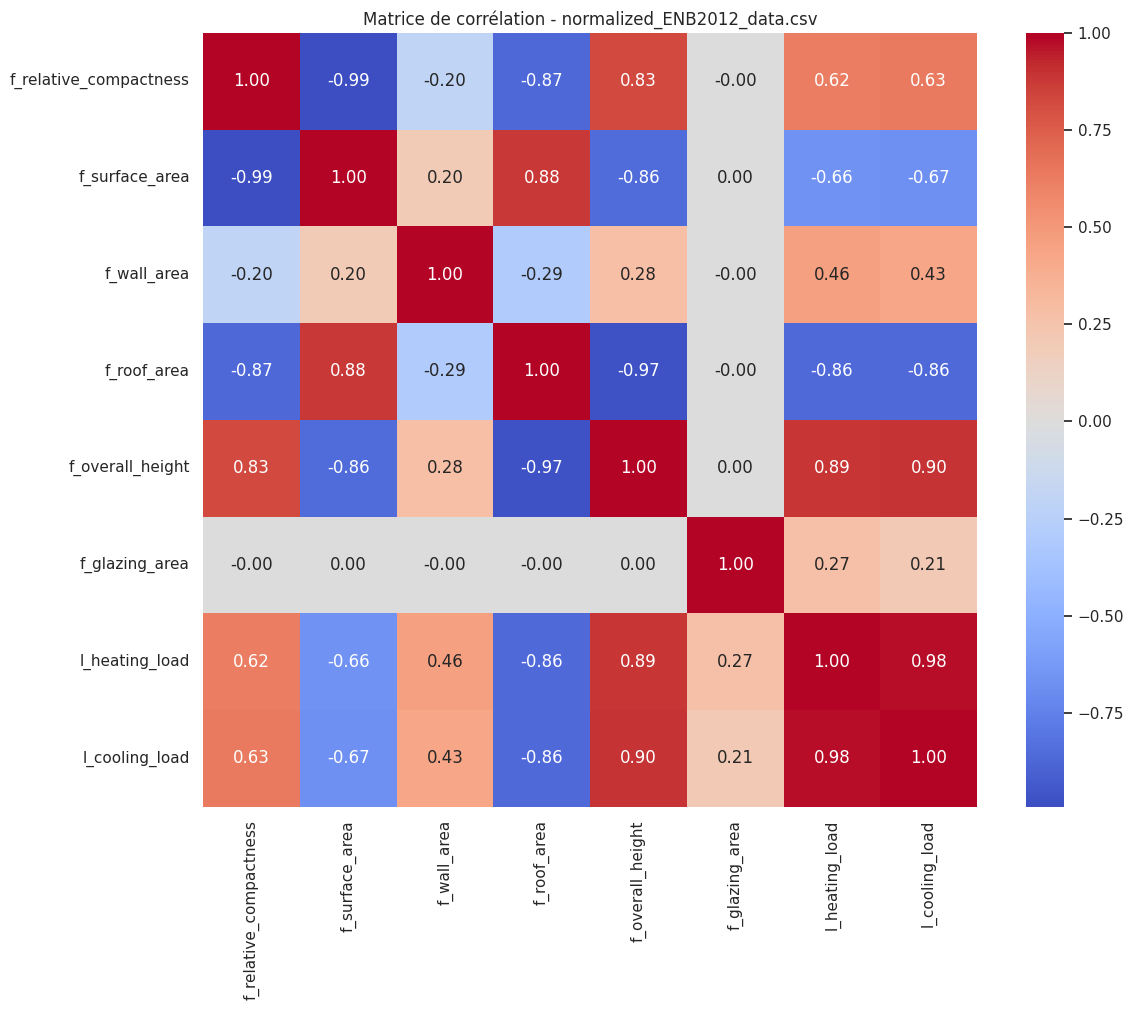

In [8]:
# Fonction pour créer la matrice de corrélation
def create_correlation_matrix(data_dict):
    """
    Crée une matrice de corrélation pour chaque DataFrame dans le dictionnaire.
    
    Args:
        data_dict (dict): Dictionnaire de DataFrames
        
    Returns:
        dict: Dictionnaire contenant les matrices de corrélation
    """
    correlation_matrices = {}
    
    for file_name, df in data_dict.items():
        print(f"Analyse du fichier {file_name}:")
        
        # Vérifier si le DataFrame est vide
        if df.empty:
            print(f"  Attention: Le DataFrame {file_name} est vide!")
            continue
            
        # Sélectionner uniquement les colonnes numériques
        numeric_cols = [col for col in df.columns if df[col].dtype in ['int64', 'float64']]
        
        # Vérifier s'il y a des colonnes numériques
        if len(numeric_cols) == 0:
            print(f"  Attention: Aucune colonne numérique trouvée dans {file_name}!")
            print("  Types de colonnes présents:", df.dtypes.unique())
            continue
            
        print(f"  Colonnes numériques trouvées: {len(numeric_cols)}")
        
        # Créer la matrice de corrélation
        corr_matrix = df[numeric_cols].corr()
        
        correlation_matrices[file_name] = corr_matrix
    
    return correlation_matrices

# Créer les matrices de corrélation pour les données normalisées converties
correlation_matrices = create_correlation_matrix(normalized_data_converted)

# Afficher les matrices de corrélation
for file_name, corr_matrix in correlation_matrices.items():
    print(f"Matrice de corrélation pour {file_name}:")
    print(corr_matrix)
    
    # Créer un heatmap
    plt.figure(figsize=(12, 10))
    sns.heatmap(corr_matrix, 
                annot=True, 
                cmap='coolwarm', 
                center=0,
                fmt='.2f',
                square=True)
    plt.title(f'Matrice de corrélation - {file_name}')
    plt.tight_layout()
    plt.show()

## 7. Test d'indépendance des variables catégorielles

### Démarche d'analyse

Pour tester l'indépendance entre les features catégorielles (f_orientation et f_glazing_distribution), nous utilisons :

- **Test exact de Fisher** :
  * H0 : Les variables sont indépendantes
  * H1 : Il existe une dépendance entre les variables
  * Interprétation : Si p-value < 0.05, on rejette H0 et on conclut à une dépendance entre les variables


In [9]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, chi2_contingency

def test_categorical_independence(df, var1, var2, alpha=0.05):
    """
    Teste l'indépendance entre deux variables catégorielles en choisissant :
      - Fisher exact si table 2×2
      - Sinon Chi² d'indépendance + Cramér's V

    Args:
        df (pd.DataFrame): DataFrame contenant les données
        var1 (str): Nom de la première variable catégorielle
        var2 (str): Nom de la deuxième variable catégorielle
        alpha (float): Seuil de signification (par défaut 0.05)
    """
    print(f"=== Indépendance entre {var1} et {var2} ===")
    # Table de contingence
    contingency = pd.crosstab(df[var1], df[var2])
    display(contingency)

    # Cas 2×2 → Fisher
    if contingency.shape == (2, 2):
        odds_ratio, p_value = fisher_exact(contingency)
        print(f"Test exact de Fisher : p-value = {p_value:.4f}, odds ratio = {odds_ratio:.2f}")
        interpr = "→ dépendance" if p_value < alpha else "→ indépendance"
        print(f"Interprétation (α={alpha}): {interpr}")
        return

    # Sinon → Chi²
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"Chi² = {chi2:.2f}, ddl = {dof}, p-value = {p:.4f}")

    # Vérifier les effectifs attendus
    low_exp = (expected < 5).sum()
    total = expected.size
    if low_exp / total > 0.2:
        print(f"⚠️ {low_exp}/{total} cases ont un effectif attendu <5 → conditions du Chi² non respectées")

    # Taille d'effet : Cramér's V
    n = contingency.values.sum()
    min_dim = min(contingency.shape) - 1
    cramers_v = np.sqrt(chi2 / (n * min_dim))
    print(f"Cramér’s V = {cramers_v:.3f}")

    interpr = "→ dépendance" if p < alpha else "→ indépendance"
    print(f"Interprétation (α={alpha}): {interpr}")

# Application à tes DataFrames
for file_name, df in normalized_data_converted.items():
    print("\n" + "="*80)
    print(f"Fichier: {file_name}")
    print("="*80)
    cats = [c for c in df.columns 
            if df[c].dtype.name == 'category' and c.startswith('f_')]
    for i in range(len(cats)):
        for j in range(i+1, len(cats)):
            test_categorical_independence(df, cats[i], cats[j])


Fichier: normalized_ENB2012_data.csv
=== Indépendance entre f_orientation et f_glazing_distribution ===


f_glazing_distribution,0,1,2,3,4,5
f_orientation,,,,,,
2,12,36,36,36,36,36
3,12,36,36,36,36,36
4,12,36,36,36,36,36
5,12,36,36,36,36,36


Chi² = 0.00, ddl = 15, p-value = 1.0000
Cramér’s V = 0.000
Interprétation (α=0.05): → indépendance


## 8. Sélection des features

### Démarche d'analyse
Nous allons appliquer l'algorithme de sélection des features en trois étapes :

1. **Sélection initiale des features numériques** :
   - Calcul de la somme des corrélations absolues avec tous les labels pour chaque feature
   - Tri des features par ordre décroissant de cette somme (les plus corrélées d'abord)
   - Sélection itérative en évitant la multicolinéarité :
     * On prend la première feature (la plus corrélée avec les labels)
     * Pour chaque feature restante, on la garde uniquement si sa corrélation avec toutes les features déjà sélectionnées est ≤ 0.85
     * Cela permet d'éviter la redondance d'information tout en gardant les features les plus pertinentes

2. **Sélection des features catégorielles** :
   - Calcul d'un score de "corrélation" pour chaque feature catégorielle :
     * Pour chaque label, on effectue un test statistique (Wilcoxon ou Kruskal-Wallis selon le nombre de classes)
     * Le score est la somme des -log(p-value) pour tous les labels
     * Plus le score est élevé, plus la feature est liée aux labels
   - Tri des features par score décroissant
   - Élimination des redondances :
     * Test de Fisher entre chaque paire de features catégorielles
     * Si dépendance détectée (p-value < 0.05), on garde celle avec le meilleur score

3. **Validation finale** :
   - Pour chaque paire (feature numérique, feature catégorielle) :
     * Test statistique pour vérifier leur indépendance
     * Si dépendance détectée (p-value < 0.05), on élimine la feature catégorielle
     * Cela permet d'éviter la redondance entre types de features différents


In [33]:
import pandas as pd
import numpy as np
from scipy import stats
from scipy.stats import chi2_contingency, fisher_exact

# Initialiser les ensembles pour stocker les features
features_to_keep = set()
features_to_eliminate = set()

for file_name, df in normalized_data_converted.items():
    print(f"\n{'='*80}")
    print(f"Sélection des features pour {file_name}")
    print(f"{'='*80}")

    # Identifier les features numériques et catégorielles
    numeric_features = [col for col in df.columns 
                        if col.startswith('f_') and df[col].dtype in ['int64', 'float64']]
    categorical_features = [col for col in df.columns 
                            if col.startswith('f_') and df[col].dtype.name == 'category']
    labels = [col for col in df.columns if col.startswith('l_')]

    # 1. Sélection des features numériques (inchangé)
    corr_sums = {feature: sum(abs(df[feature].corr(df[label])) for label in labels)
                 for feature in numeric_features}
    sorted_features = sorted(corr_sums.items(), key=lambda x: x[1], reverse=True)
    selected_numeric = []
    for feature, _ in sorted_features:
        if not selected_numeric:
            selected_numeric.append(feature)
        else:
            if all(abs(df[feature].corr(df[f])) <= 0.85 for f in selected_numeric):
                selected_numeric.append(feature)
    print("Features numériques sélectionnées:", selected_numeric)

    # 2. Sélection des features catégorielles
    #    calcul de score (Wilcoxon ou Kruskal) inchangé
    categorical_scores = {}
    for feature in categorical_features:
        total_score = 0
        for label in labels:
            groups = [g[label].values for _, g in df.groupby(feature, observed=False)]
            if len(groups) == 2:
                _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                _, p = stats.kruskal(*groups)
            total_score += -np.log(p) if p > 0 else 1000
        categorical_scores[feature] = total_score

    sorted_categorical = [f for f, _ in sorted(categorical_scores.items(), key=lambda x: x[1], reverse=True)]
    to_eliminate = set()

    # Boucle d'élimination basée sur dépendance entre paires
    for i in range(len(sorted_categorical)):
        f1 = sorted_categorical[i]
        if f1 in to_eliminate:
            continue
        for f2 in sorted_categorical[i+1:]:
            if f2 in to_eliminate:
                continue

            # 2×2 ? Fisher : sinon Chi²
            contingency = pd.crosstab(df[f1], df[f2])
            if contingency.shape == (2, 2):
                _, p_val = fisher_exact(contingency)
            else:
                _, p_val, _, _ = chi2_contingency(contingency)

            if p_val < 0.05:
                # on élimine la moins « informative »
                if categorical_scores[f1] >= categorical_scores[f2]:
                    to_eliminate.add(f2)
                else:
                    to_eliminate.add(f1)
                    break

    selected_categorical = [f for f in sorted_categorical if f not in to_eliminate]
    print("Features catégorielles sélectionnées:", selected_categorical)

    # 3. Dernière passe : dépendance catégorielle vs numérique (inchangé)
    categorical_to_eliminate = set()
    for cat in selected_categorical:
        for num in selected_numeric:
            groups = [g[num].values for _, g in df.groupby(cat, observed=False)]
            if len(groups) == 2:
                _, p = stats.mannwhitneyu(groups[0], groups[1], alternative='two-sided')
            else:
                _, p = stats.kruskal(*groups)
            if p < 0.05:
                categorical_to_eliminate.add(cat)
                break

    final_categorical = [f for f in selected_categorical if f not in categorical_to_eliminate]

    # Mise à jour des ensembles globaux
    features_to_keep.update(selected_numeric + final_categorical)
    features_to_eliminate.update(
        [f for f in numeric_features if f not in selected_numeric] +
        [f for f in categorical_features if f not in final_categorical]
    )

    # Résumé
    print("\nRésultats finaux:")
    print(" → Conservées :", selected_numeric + final_categorical)
    print(" → Éliminées :", sorted(to_eliminate | categorical_to_eliminate))

    # Affichage d’un tableau récapitulatif
    summary = []
    for feat in numeric_features + categorical_features:
        status = "Conservée" if feat in features_to_keep else "Éliminée"
        if feat in selected_numeric:
            reason = "Corrélation élevée avec labels"
        elif feat in final_categorical:
            reason = "Score élevé et indépendance validée"
        elif feat in to_eliminate:
            reason = "Dépendance entre catégorielles"
        elif feat in categorical_to_eliminate:
            reason = "Dépendance avec numérique"
        else:
            reason = "Score insuffisant"
        summary.append({
            'Feature': feat,
            'Type': 'Numérique' if feat in numeric_features else 'Catégorielle',
            'Status': status,
            'Raison': reason
        })
    summary_df = pd.DataFrame(summary)
    display(
        summary_df.style
            .set_properties(**{'text-align': 'left'})
            .set_table_styles([
                {'selector': 'th', 'props': [('text-align', 'left')]},
                {'selector': 'td', 'props': [('text-align', 'left')]}
            ])
            .hide(axis='index')
    )

# Enfin, construire le dictionnaire filtré
normalized_data_converted_selected = {}
for fname, df in normalized_data_converted.items():
    cols_to_drop = [f for f in df.columns if f in features_to_eliminate]
    normalized_data_converted_selected[fname] = df.drop(columns=cols_to_drop)



Sélection des features pour normalized_ENB2012_data.csv
Features numériques sélectionnées: ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area']
Features catégorielles sélectionnées: ['f_glazing_distribution', 'f_orientation']

Résultats finaux:
 → Conservées : ['f_overall_height', 'f_relative_compactness', 'f_wall_area', 'f_glazing_area', 'f_orientation']
 → Éliminées : ['f_glazing_distribution']


Feature,Type,Status,Raison
f_relative_compactness,Numérique,Conservée,Corrélation élevée avec labels
f_surface_area,Numérique,Éliminée,Score insuffisant
f_wall_area,Numérique,Conservée,Corrélation élevée avec labels
f_roof_area,Numérique,Éliminée,Score insuffisant
f_overall_height,Numérique,Conservée,Corrélation élevée avec labels
f_glazing_area,Numérique,Conservée,Corrélation élevée avec labels
f_orientation,Catégorielle,Conservée,Score élevé et indépendance validée
f_glazing_distribution,Catégorielle,Éliminée,Dépendance avec numérique


## 9. Définitions des fonctions de transformation

In [34]:
# vos autres transform et inverse-transform
TRANSFORM_FNS = {
    'none':   lambda x: x,
    'log':    np.log,
    'log1p':  np.log1p,
    'sqrt':   np.sqrt,
    'cbrt':   np.cbrt,
    'square': lambda x: x**2,
    'cube':   lambda x: x**3,
    'power4': lambda x: x**4,
}

INV_TRANSFORM_FNS = {
    'none':   lambda x: x,
    'log':    np.exp,
    'log1p':  np.expm1,
    'sqrt':   lambda x: x**2,
    'cbrt':   lambda x: x**3,
    'square': np.sqrt,
    'cube':   np.cbrt,
    'power4': lambda x: x**(1/4),
}

def apply_transform(series: pd.Series, method: str):
    """
    Retourne soit:
      - (serie_t, lambda) pour boxcox
      - serie_t pour les autres méthodes
    """
    if method == 'boxcox':
        # on s'assure que la série est strictement positive
        if (series <= 0).any():
            shift = -series.min() + 1e-6
            series = series + shift
            print(f"⚠ {method}: data shifted by +{shift:.6f} pour être >0")
        transformed, lmbda = boxcox(series.values)
        return transformed, lmbda
    else:
        fn = TRANSFORM_FNS.get(method)
        if fn is None:
            raise ValueError(f"Transformation inconnue: {method}")
        return fn(series.values)

def inverse_transform(y, method: str, lmbda=None):
    """
    Applique l'inverse de la transformation.
    Pour boxcox, il faut fournir λ.
    """
    if method == 'boxcox':
        if lmbda is None:
            raise ValueError("λ manquant pour l'inverse de boxcox")
        # inverse analytique
        y = np.asarray(y)
        if lmbda == 0:
            return np.exp(y)
        else:
            return (y * lmbda + 1) ** (1.0 / lmbda)
    else:
        fn = INV_TRANSFORM_FNS.get(method)
        if fn is None:
            raise ValueError(f"Transformation inverse inconnue: {method}")
        return fn(y)

l_transformations = ['log', 'sqrt', 'square', 'cube', 'power4', 'cbrt']
#f_transformations = ['log', 'sqrt', 'square']
#f_transformations = ['boxcox', 'log', 'sqrt', 'square', 'cube', 'power4', 'cbrt']#KO
#f_transformations = ['boxcox', 'log', 'sqrt', 'square']#KO
f_transformations = ['log', 'sqrt', 'square']#OK
#f_transformations = ['log', 'sqrt', 'square', 'cube', 'power4', 'cbrt']#KO
#f_transformations = ['log', 'sqrt', 'square', 'cube', 'cbrt']#KO
#f_transformations = ['log', 'sqrt', 'square', 'cube']#KO
#f_transformations = ['log', 'sqrt', 'square', 'cbrt']#KO
#f_transformations = ['log', 'sqrt', 'square', 'power4']#KO
#f_transformations = ['log', 'sqrt', 'power4']#KO
#f_transformations = ['log', 'sqrt', 'cube']#KO
#f_transformations = ['sqrt','square', 'cube']#KO
#f_transformations = ['log','square', 'cube']#KO
#l_transformations = ['log', 'sqrt', 'square']


## 10. Analyse des distributions des labels

### Objectif
Analyser la distribution des variables cibles (labels) pour identifier des transformations potentielles qui pourraient améliorer leur adéquation avec un modèle linéaire.

Pour chaque label, nous allons :
1. Visualiser sa distribution avec un histogramme et une courbe de densité
2. Calculer les statistiques descriptives (moyenne, médiane, écart-type, skewness, kurtosis)
3. Tester différentes transformations (log, racine carrée, carré, cube)
4. Visualiser les distributions transformées
5. Calculer les statistiques des distributions transformées
6. Recommander les transformations les plus pertinentes


In [35]:
boxcox_lambdas = {}

def analyze_distribution(df: pd.DataFrame, column: str, l_transformations: list):
    global boxcox_lambdas
    print(f"--- Analyse de '{column}' ---")
    data = df[column].dropna()
    # stats de base
    print(data.agg(['mean','median','std','skew','kurtosis']))
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    axes_list = [axes[i,j] for i in range(3) for j in range(3) if not (i==2 and j==2)]
    
    for ax, method in zip(axes_list, l_transformations):
        try:
            if method == 'boxcox':
                series_t, lmbda = apply_transform(data, method)
                boxcox_lambdas[column] = lmbda
                title = f"Box–Cox (λ={lmbda:.3f})"
            else:
                series_t = apply_transform(data, method)
                title = method.capitalize()
        except Exception as e:
            print(f"⚠ Erreur sur '{method}': {e}")
            # on continue sans masquer l'axe, pour avoir le titre en rouge
            ax.set_title(f"{method} : ERREUR")
            ax.text(0.5, 0.5, str(e),
                    ha='center', va='center', transform=ax.transAxes,
                    color='red', wrap=True)
            continue
        
        ax.hist(series_t, bins=30, edgecolor='black')
        ax.set_title(title)
        stats_t = pd.Series(series_t).agg(['skew','kurtosis'])
        ax.text(0.95, 0.95,
                f"Skew: {stats_t['skew']:.2f}\nKurt: {stats_t['kurtosis']:.2f}",
                transform=ax.transAxes, ha='right', va='top')
    
    # QQ-plot
    ax_qq = axes[2,2]
    probplot(data, dist='norm', plot=ax_qq)
    ax_qq.set_title('QQ-plot (original)')
    
    plt.tight_layout(rect=[0,0.03,1,0.95])
    plt.show()


Analyse des distributions pour le fichier : normalized_ENB2012_data.csv

Analyse de la distribution de l_heating_load
--- Analyse de 'l_heating_load' ---
mean        22.307195
median      18.950000
std         10.090204
skew         0.360446
kurtosis    -1.245569
Name: l_heating_load, dtype: float64


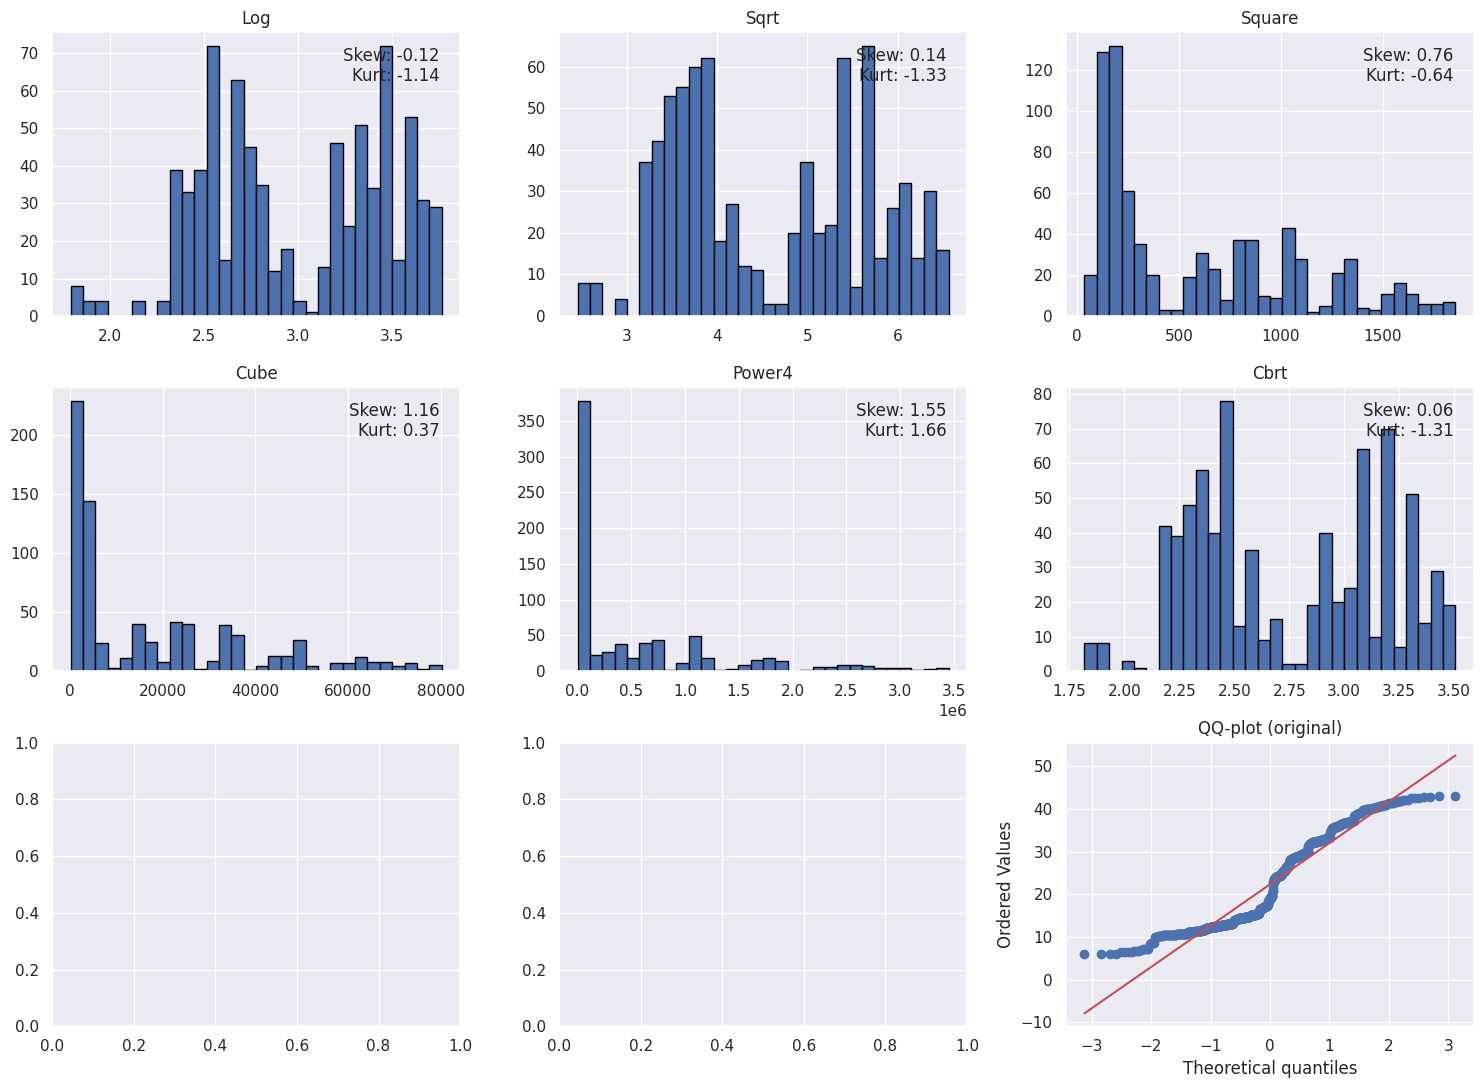


Analyse de la distribution de l_cooling_load
--- Analyse de 'l_cooling_load' ---
mean        24.587760
median      22.080000
std          9.513306
skew         0.395992
kurtosis    -1.147190
Name: l_cooling_load, dtype: float64


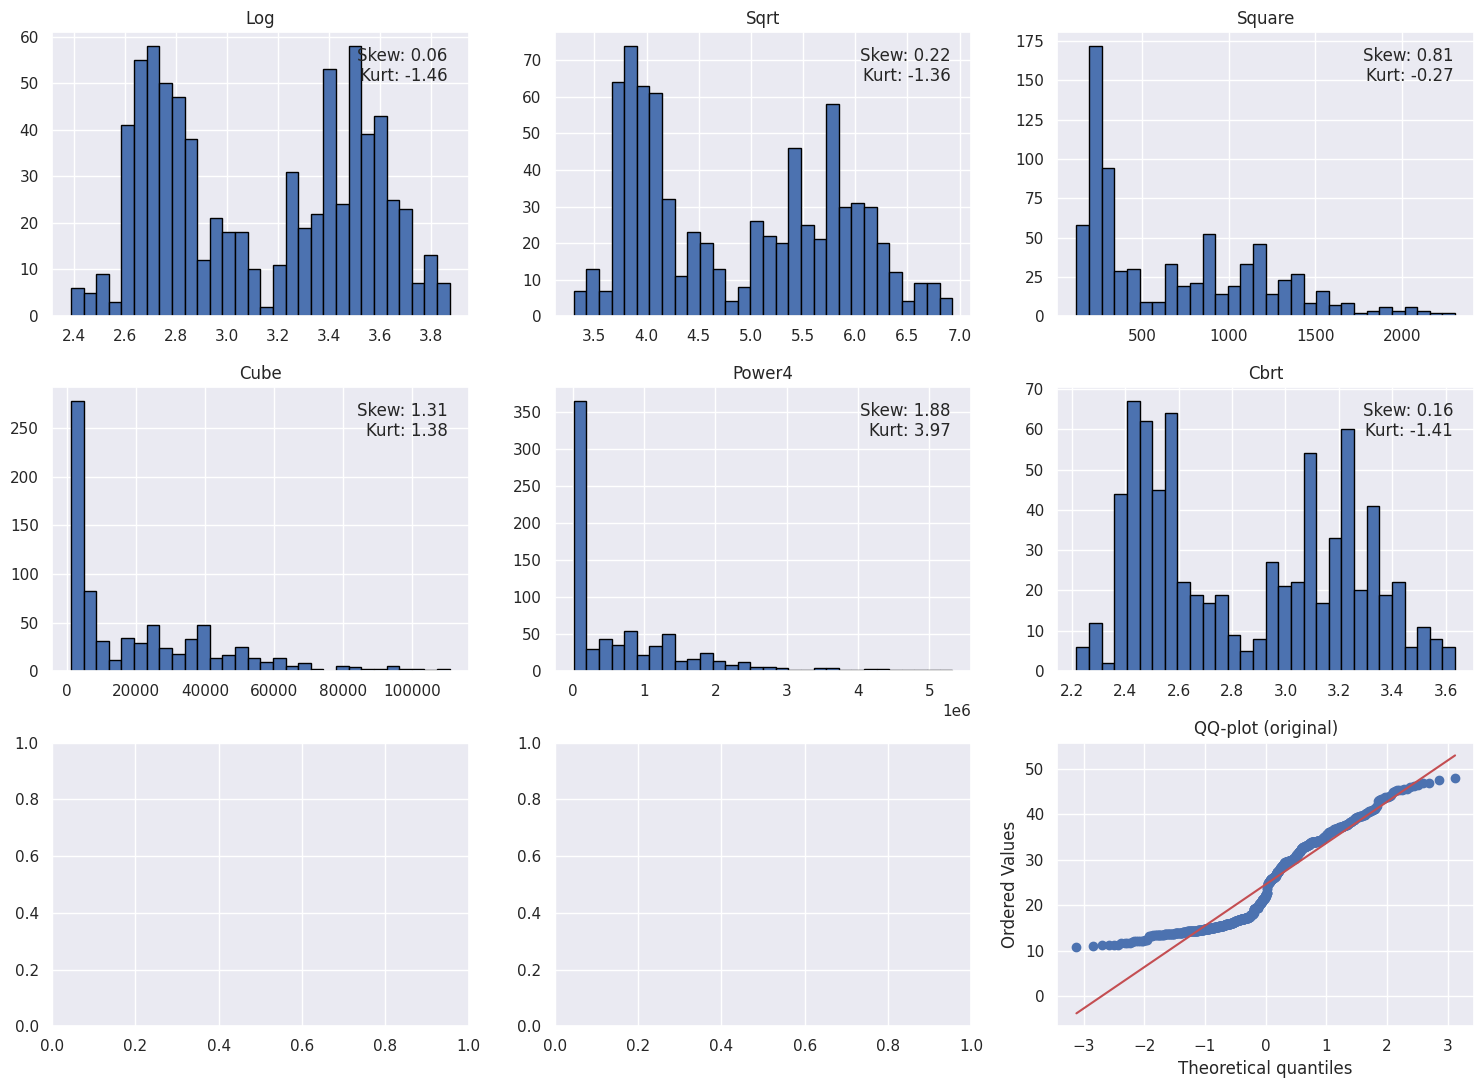

In [36]:
# Analyse des distributions pour chaque label
for file_name, df in normalized_data_converted_selected.items():
    print(f"\nAnalyse des distributions pour le fichier : {file_name}")
    for label in labels:
        print(f"\nAnalyse de la distribution de {label}")
        analyze_distribution(df, label,l_transformations)


## 11. Analyse GPT des distributions

### Objectif
Utiliser un modèle GPT pour analyser les résultats des transformations et recommander la transformation la plus appropriée pour chaque label dans le cadre d'un modèle linéaire.


In [37]:
# On suppose que l_transformations, boxcox_lambdas, apply_transform, inverse_transform sont déjà importés

def analyze_distributions_with_gpt(
    file_name: str,
    df: pd.DataFrame,
    labels: list,
    l_transformations: list
) -> list:
    """
    Pour chaque label de df, calcule skew/kurt avant et après transformations,
    stocke λ de boxcox, et interroge l'API OpenAI pour obtenir une recommandation.
    """
    load_dotenv()
    if not os.getenv("OPENAI_API_KEY"):
        raise RuntimeError("La clé OPENAI_API_KEY n'est pas définie.")
    openai.api_key = os.getenv("OPENAI_API_KEY")
    
    # 1) Construire label_stats
    label_stats = {}
    for label in labels:
        series = df[label].dropna()
        orig_skew = float(series.skew())
        orig_kurt = float(series.kurtosis())
        
        trans_stats = {}
        for method in l_transformations:
            if method == "boxcox":
                data_t, lmbda = apply_transform(series, method)
                boxcox_lambdas[label] = lmbda
            else:
                data_t = apply_transform(series, method)
            
            s = pd.Series(data_t)
            trans_stats[method] = {
                "skewness": float(s.skew()),
                "kurtosis": float(s.kurtosis())
            }
        
        label_stats[label] = {
            "original": {"skewness": orig_skew, "kurtosis": orig_kurt},
            "transformations": trans_stats
        }
    
    # 2) Pour chaque label, on appelle l'API
    recommendations = []
    for label, stats in label_stats.items():
        # Construire le prompt_str
        prompt_str = (
            f"Analyse la distribution de la variable **{label}** du fichier **{file_name}** "
            f"et recommande la meilleure transformation pour un modèle linéaire.\n\n"
            f"Statistiques originales :\n"
            f"- Skewness : {stats['original']['skewness']:.2f}\n"
            f"- Kurtosis : {stats['original']['kurtosis']:.2f}\n\n"
            "Statistiques après transformations :\n"
        )
        for method, tstats in stats["transformations"].items():
            prompt_str += (
                f"- {method} : skewness={tstats['skewness']:.2f}, "
                f"kurtosis={tstats['kurtosis']:.2f}\n"
            )
        prompt_str += (
            "\nRecommandation :\n"
            "1. Identifie la transformation qui donne la distribution la plus proche d'une loi normale.\n"
            "2. Justifie ton choix à partir des mesures de skewness et kurtosis.\n"
            "3. Répond au format JSON :\n"
            "{\n"
            '  "label": "nom_du_label",\n'
            '  "transformation": "nom_de_la_transformation_recommandée",\n'
            '  "justification": "…"\n'
            "}\n"
        )

        messages = [
            {"role": "system", "content": "Tu es un expert en analyse de données et en statistiques."},
            {"role": "user",   "content": prompt_str}
        ]

        try:
            resp = openai.chat.completions.create(
                model="gpt-3.5-turbo",
                messages=messages,
                temperature=0.7
            )
            text = resp.choices[0].message.content
            # Extraction robuste du JSON
            start = text.find("{")
            end = text.rfind("}") + 1
            rec = json.loads(text[start:end])
        except Exception as e:
            print(f"⚠ Erreur GPT pour '{label}': {e}")
            rec = {
                "label": label,
                "transformation": "none",
                "justification": f"Erreur GPT ou parsing : {e}"
            }
        if rec["transformation"].lower() not in l_transformations:
            rec = {
                "label": label,
                "transformation": "none",
                "justification": f"Transformation non prise en compte"
            }

        recommendations.append(rec)

    return recommendations

In [38]:
gpt_results = {}
features_to_eliminate = set()

for file_name, df in normalized_data_converted_selected.items():
    print("=" * 80)
    print(f"Analyse GPT des distributions pour {file_name}")
    print("=" * 80)

    labels = [c for c in df.columns if c.startswith("l_")]

    recs = analyze_distributions_with_gpt(
        file_name=file_name,
        df=df,
        labels=labels,
        l_transformations=l_transformations
    )
    gpt_results[file_name] = recs

    print("Résultats de l'analyse GPT :")
    for r in recs:
        print(f"Analyse pour {r['label']}:")
        print(f"  Transformation recommandée : {r['transformation']}")
        print(f"  Justification : {r['justification']}")
        print("-" * 40)
        if r["transformation"].lower() == "none":
            features_to_eliminate.add(r["label"])


Analyse GPT des distributions pour normalized_ENB2012_data.csv
Résultats de l'analyse GPT :
Analyse pour l_heating_load:
  Transformation recommandée : log
  Justification : La transformation logarithmique est recommandée car elle réduit le skewness de la distribution à -0.12, qui est le plus proche de 0, et diminue le kurtosis à -1.14, se rapprochant de la normalité. Les autres transformations présentent des valeurs de skewness et kurtosis moins proches de 0 et -3 respectivement, ce qui indique une distribution moins proche d'une loi normale.
----------------------------------------
Analyse pour l_cooling_load:
  Transformation recommandée : log
  Justification : La transformation log donne la distribution la plus proche d'une loi normale, avec une skewness proche de zéro et un kurtosis plus négatif, ce qui indique une distribution plus proche de la normale. Les autres transformations présentent des valeurs de skewness et kurtosis moins favorables, indiquant une plus grande asymétrie 

## 12. Transformation des labels et visualisation

### Objectif
Transformer les labels selon les recommandations de GPT et visualiser l'impact des transformations sur les relations avec les features conservées uniquement.


Transformation des labels pour normalized_ENB2012_data.csv
Transformation de l_heating_load avec log :
  Avant  – Skewness: 0.36, Kurtosis: -1.25
  Après  – Skewness: -0.12, Kurtosis: -1.14
Transformation de l_cooling_load avec log :
  Avant  – Skewness: 0.40, Kurtosis: -1.15
  Après  – Skewness: 0.06, Kurtosis: -1.46
Graphiques pour l_heating_load :


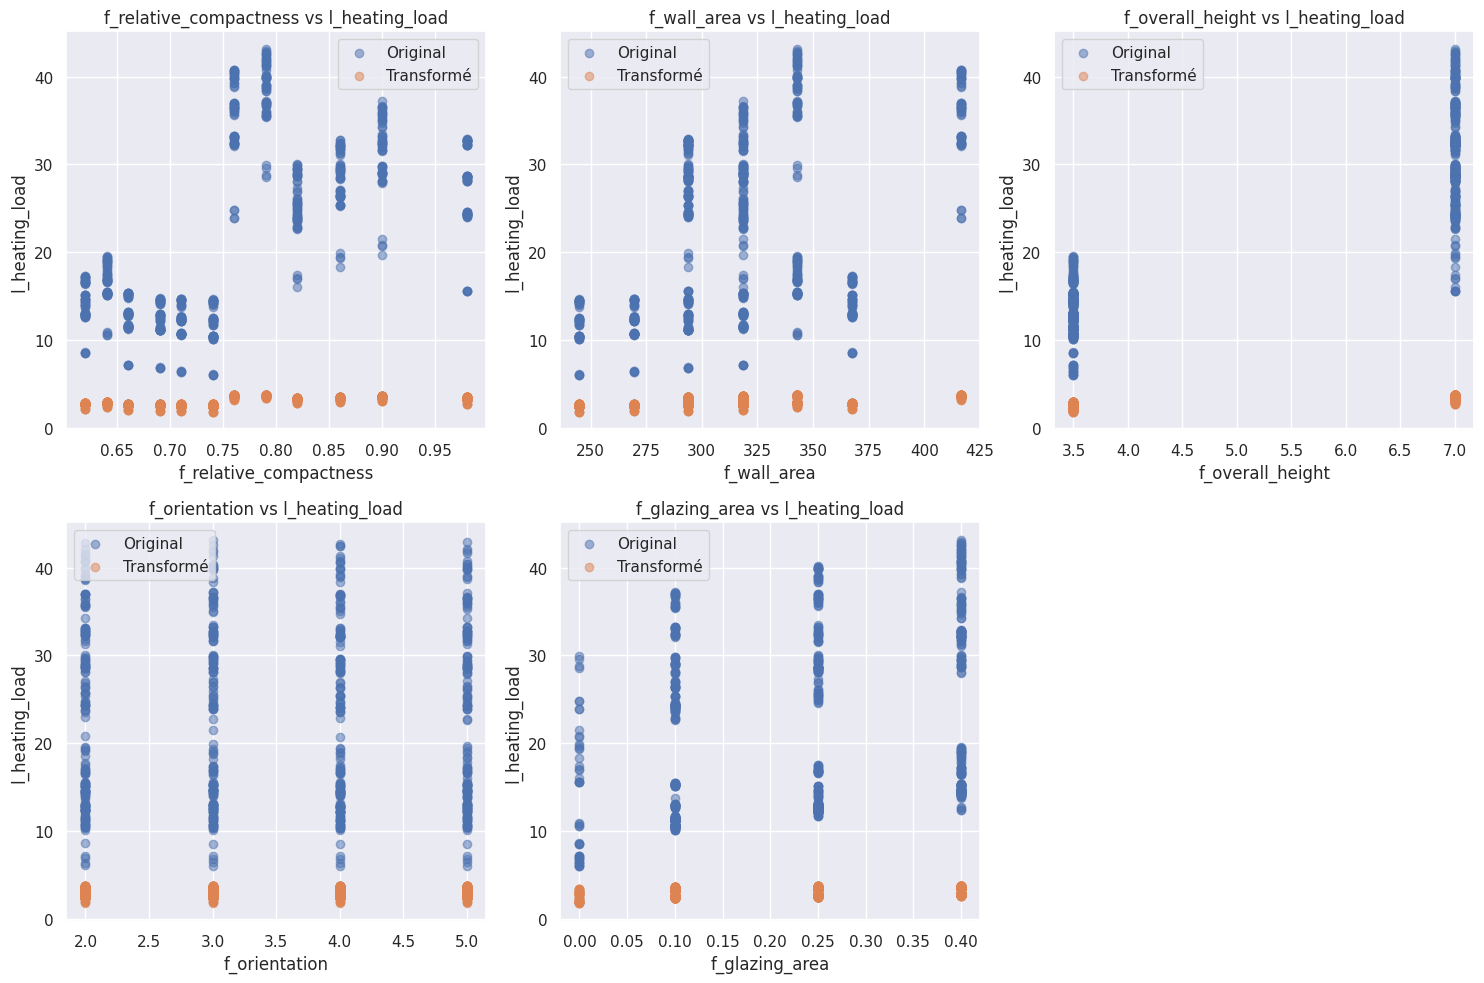

Matrices de corrélation :


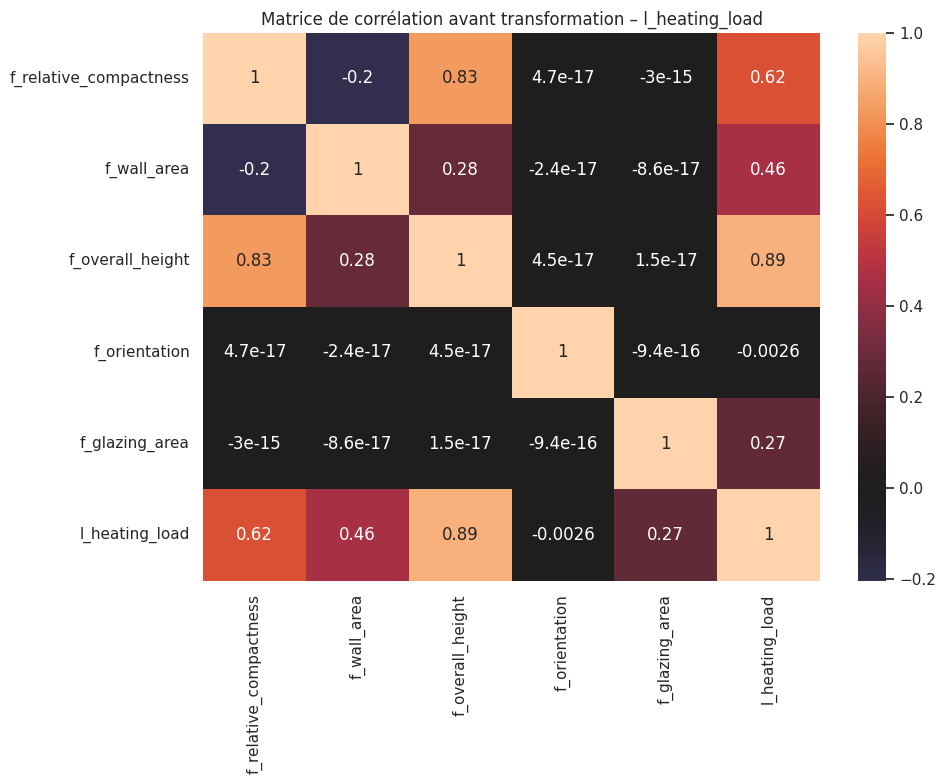

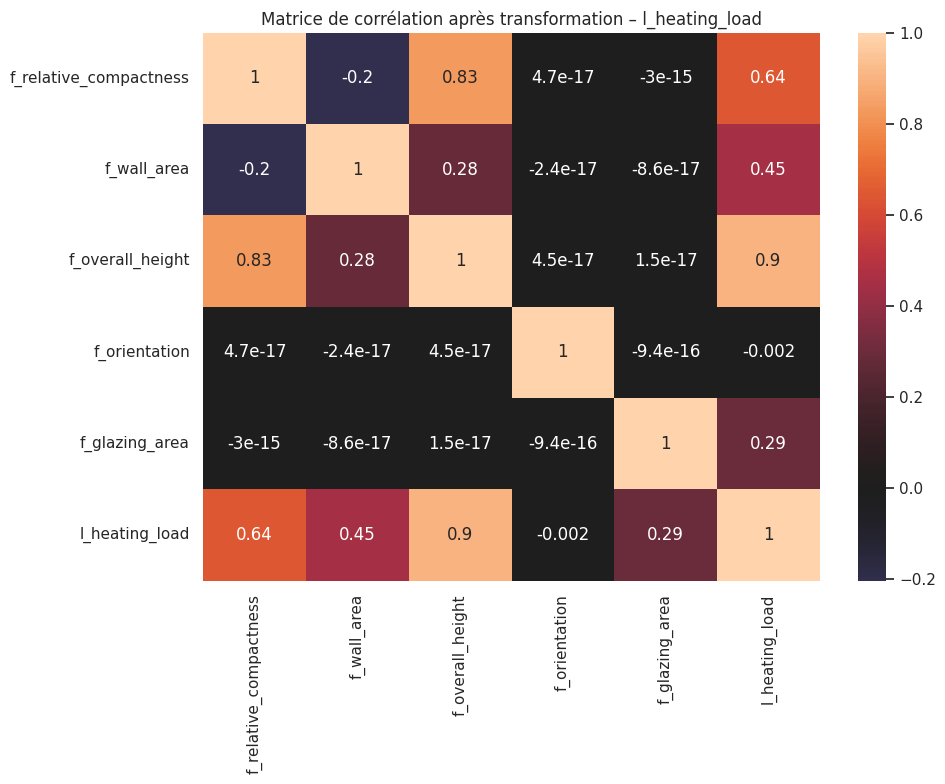

Graphiques pour l_cooling_load :


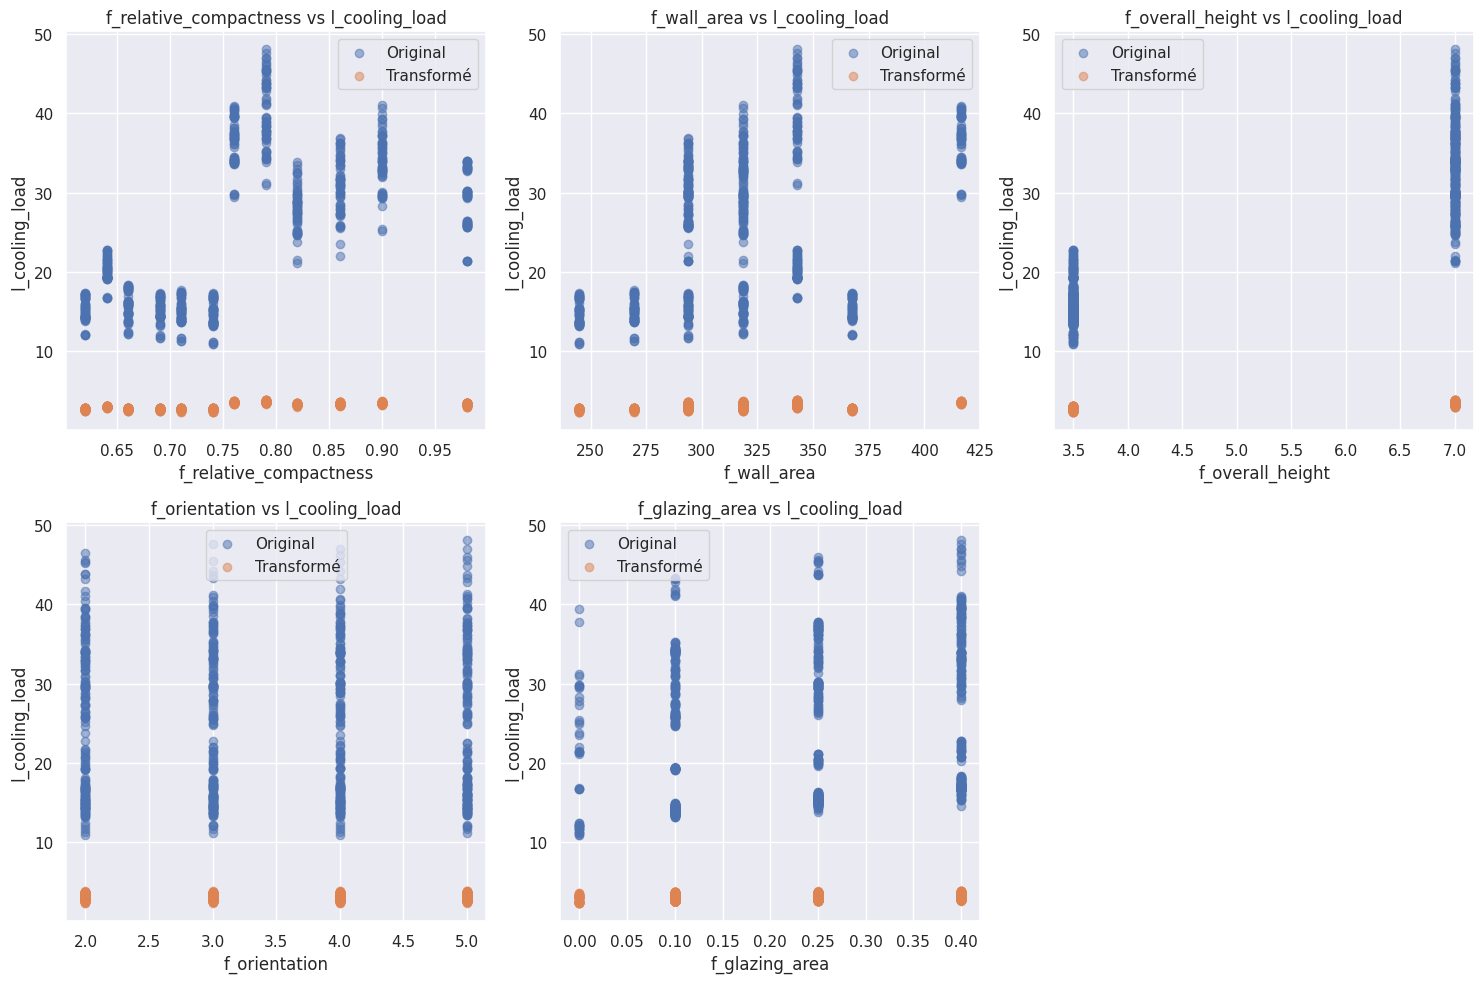

Matrices de corrélation :


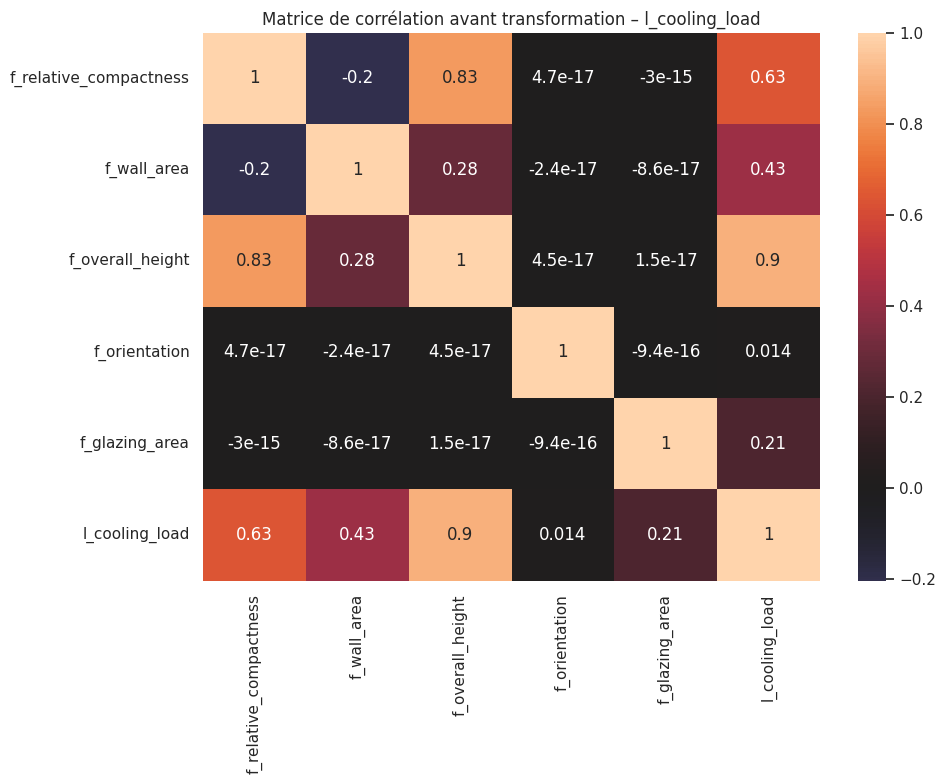

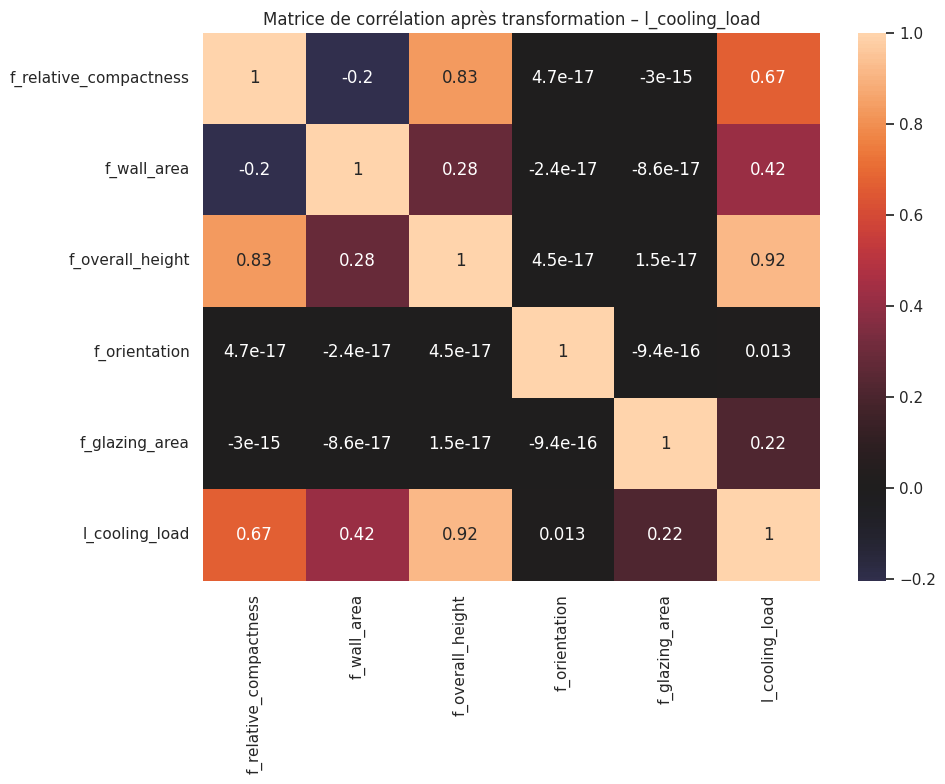

In [39]:
# Transformer les labels selon les recommandations de GPT
data_label_trans = normalized_data_converted_selected.copy()

for file_name, df in data_label_trans.items():
    print("=" * 80)
    print(f"Transformation des labels pour {file_name}")
    print("=" * 80)

    recs = gpt_results.get(file_name, [])
    if not recs:
        continue

    # Copie du DataFrame pour stocker les labels transformés
    df_transformed = df.copy()

    for rec in recs:
        label = rec["label"]
        method = rec["transformation"].lower()

        if method == "none":
            continue

        print(f"Transformation de {label} avec {method} :")
        try:
            if method == "boxcox":
                # apply_transform renvoie (série_t, λ)
                series_t, lmbda = apply_transform(df[label], "boxcox")
                boxcox_lambdas[label] = lmbda
            else:
                series_t = apply_transform(df[label], method)

            # On remplace la colonne transformée
            df_transformed[label+"_orig"] = df_transformed[label]
            df_transformed[label] = series_t
            data_label_trans[file_name] = df_transformed
            
            # Affichage des stats avant / après
            orig_skew, orig_kurt = df[label].skew(), df[label].kurtosis()
            new_skew, new_kurt = df_transformed[label].skew(), df_transformed[label].kurtosis()
            print(f"  Avant  – Skewness: {orig_skew:.2f}, Kurtosis: {orig_kurt:.2f}")
            print(f"  Après  – Skewness: {new_skew:.2f}, Kurtosis: {new_kurt:.2f}")

        except Exception as e:
            print(f"⚠ Erreur pendant la transformation {method} de {label} : {e}")

    # Sélection des features et labels
    features = [c for c in df.columns if c.startswith("f_") and c in features_to_keep]
    labels = [c for c in df.columns if c.startswith("l_") and not(c.endswith("_orig"))]

    for label in labels:
        print(f"Graphiques pour {label} :")
        n_features = len(features)
        n_cols = 3
        n_rows = (n_features + n_cols - 1) // n_cols

        fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
        axes = axes.flatten()

        for i, feature in enumerate(features):
            ax = axes[i]
            # Original vs Transformé
            ax.scatter(df[feature], df[label], alpha=0.5, label="Original")
            ax.scatter(df[feature], df_transformed[label], alpha=0.5, label="Transformé")
            ax.set_xlabel(feature)
            ax.set_ylabel(label)
            ax.set_title(f"{feature} vs {label}")
            ax.legend()

        # Masquer les axes restants
        for j in range(len(features), len(axes)):
            axes[j].set_visible(False)

        plt.tight_layout()
        plt.show()

        # Matrices de corrélation avant et après
        print("Matrices de corrélation :")

        corr_before = df[features + [label]].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_before, annot=True, center=0)
        plt.title(f"Matrice de corrélation avant transformation – {label}")
        plt.tight_layout()
        plt.show()

        corr_after = df_transformed[features + [label]].corr()
        plt.figure(figsize=(10, 8))
        sns.heatmap(corr_after, annot=True, center=0)
        plt.title(f"Matrice de corrélation après transformation – {label}")
        plt.tight_layout()
        plt.show()

## 13. Création de features polynomiales pour les relations non-linéaires

### Objectif
Pour chaque feature qui présente une relation non-linéaire avec un des labels, créer des transformations polynomiales :
- log
- racine carrée
- racine cubique
- carré
- cube
- puissance 4

Ces nouvelles features seront utilisées dans la sélection de modèles qui suit.

### Critère de non-linéarité
Une feature est considérée comme ayant une relation non-linéaire potentielle avec le label si sa corrélation est modérée, c'est-à-dire entre 0.33 et 0.66 (en valeur absolue).


Création des features polynomiales pour normalized_ENB2012_data.csv

Analyse pour le label l_heating_load :
Features sélectionnées : ['f_relative_compactness', 'f_wall_area']
– 6 nouvelles colonnes créées
Exemple (5 premières) :


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_square,f_wall_area_log,f_wall_area_sqrt
0,-0.020203,0.989949,0.9604,5.683580,17.146428
1,-0.020203,0.989949,0.9604,5.683580,17.146428
2,-0.020203,0.989949,0.9604,5.683580,17.146428
3,-0.020203,0.989949,0.9604,5.683580,17.146428
4,-0.105361,0.948683,0.8100,5.763622,17.846568


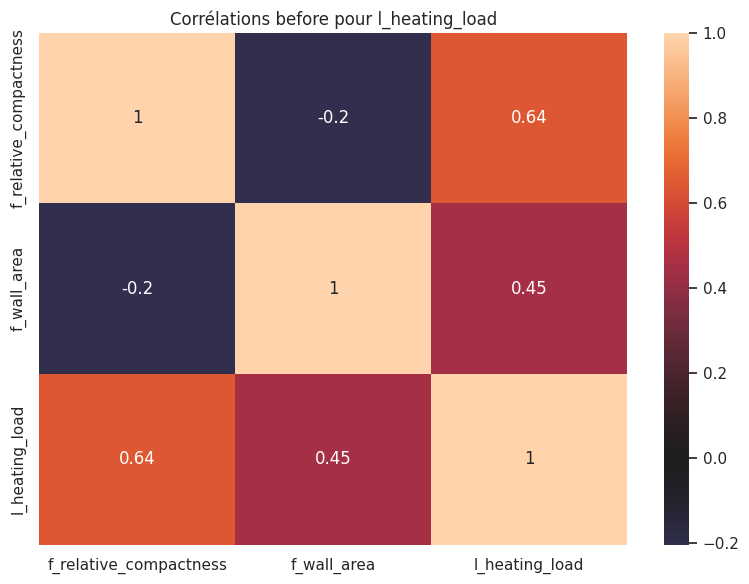

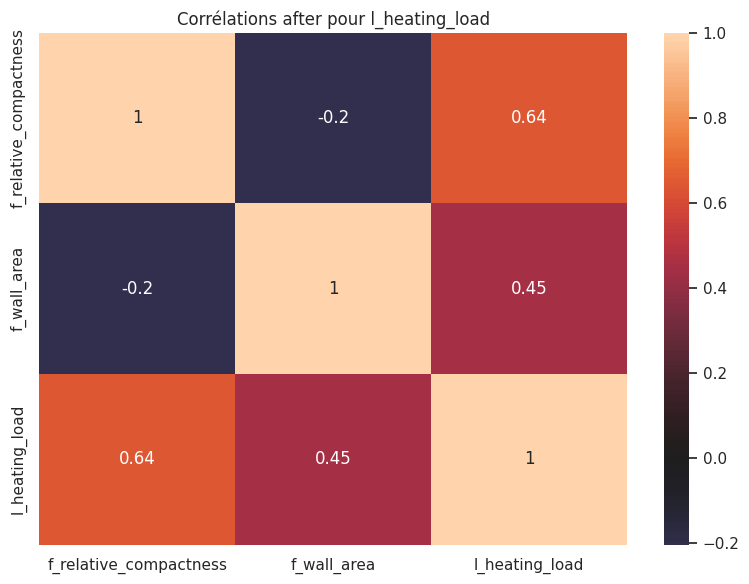


Analyse pour le label l_cooling_load :
Features sélectionnées : ['f_wall_area']
– 6 nouvelles colonnes créées
Exemple (5 premières) :


,f_relative_compactness_log,f_relative_compactness_sqrt,f_relative_compactness_square,f_wall_area_log,f_wall_area_sqrt
0,-0.020203,0.989949,0.9604,5.683580,17.146428
1,-0.020203,0.989949,0.9604,5.683580,17.146428
2,-0.020203,0.989949,0.9604,5.683580,17.146428
3,-0.020203,0.989949,0.9604,5.683580,17.146428
4,-0.105361,0.948683,0.8100,5.763622,17.846568


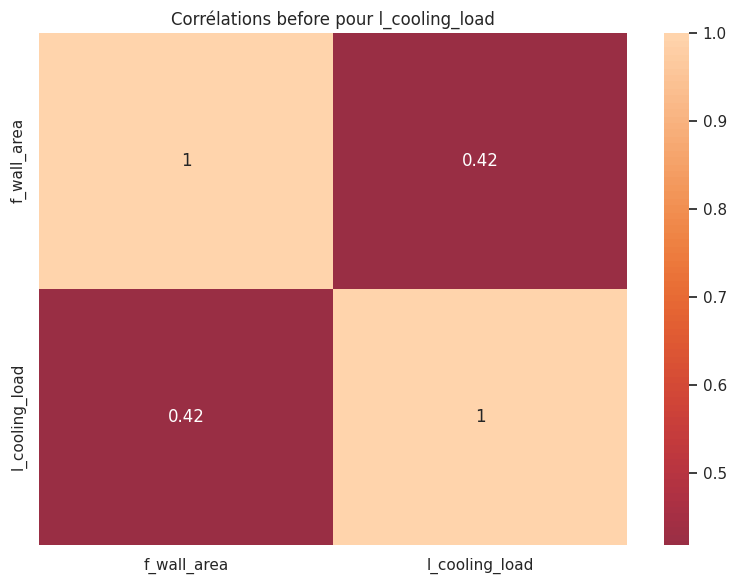

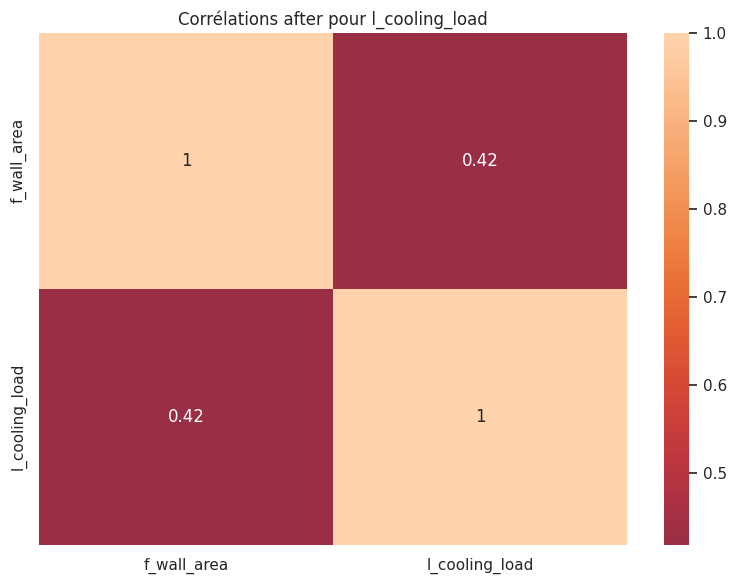


Tableau de synthèse :


Fichier,Label,Feature,Corr. avant,Transforms
normalized_ENB2012_data.csv,l_heating_load,f_relative_compactness,0.644,"log, sqrt, square"
normalized_ENB2012_data.csv,l_heating_load,f_wall_area,0.448,"log, sqrt, square"
normalized_ENB2012_data.csv,l_cooling_load,f_wall_area,0.419,"log, sqrt, square"


In [40]:
# On suppose que f_transformations et boxcox_lambdas sont définis ailleurs :
# f_transformations = ['log', 'sqrt', 'square']
# boxcox_lambdas = { 'l_heating_load': 0.123, ... }

def get_polynomial_features(df: pd.DataFrame, target_col: str) -> list:
    """
    Sélectionne les features dont la corrélation absolue avec target_col est
    dans (0.33, 0.66), hors la colonne cible elle-même.
    """
    corrs = df.corr()[target_col].abs()
    feats = corrs[(corrs > 0.33) & (corrs < 0.66)].index.tolist()
    return [f for f in feats if f != target_col]

def create_polynomial_features(
    df: pd.DataFrame,
    features: list,
    transformations: list = f_transformations
) -> pd.DataFrame:
    """
    Pour chaque feature, génère des colonnes feat_method selon `transformations`.
    Pour 'boxcox', calcule d'abord le λ via boxcox_normmax, 
    stocke λ dans boxcox_lambdas[feat] et transforme.
    """
    df_poly = df.copy()
    for feat in features:
        x = df[feat].dropna().values
        for method in transformations:
            if method == 'boxcox':
                # on passe directement la Series à apply_transform
                series_t, lmbda = apply_transform(df[feat], method)
                boxcox_lambdas[feat] = lmbda
                df_poly[f"{feat}_boxcox"] = series_t
            else:
                # autres transformations via apply_transform
                df_poly[f"{feat}_{method}"] = apply_transform(df[feat], method)
    return df_poly

# stockage des résultats
polynomial_analysis_results = {}
normalized_data_pol_sel = {}

for file_name, df in data_label_trans.items():
    print("="*80)
    print(f"Création des features polynomiales pour {file_name}")
    print("="*80)
    
    # on part d'une copie
    df_poly = df.copy()
    
    labels = [c for c in df.columns if c.startswith('l_') and not(c.endswith("_orig"))]
    for label in labels:
        print(f"\nAnalyse pour le label {label} :")
        feats = get_polynomial_features(df, label)
        if not feats:
            print("Aucune feature sélectionnée pour transformation.")
            continue
        
        print(f"Features sélectionnées : {feats}")
        # création des features
        df_poly = create_polynomial_features(df_poly, feats)
        normalized_data_pol_sel[file_name] = df_poly
        
        # bilan
        new_cols = [c for c in df_poly.columns if c not in df.columns]
        print(f"– {len(new_cols)} nouvelles colonnes créées")
        print("Exemple (5 premières) :")
        display(df_poly[new_cols[:5]].head())
        
        # stocker corrélations avant
        corrs_before = {f: df[f].corr(df[label]) for f in feats}
        polynomial_analysis_results[(file_name, label)] = {
            "features": feats,
            "new_columns": new_cols,
            "correlations_before": corrs_before
        }
        
        # optionnel : afficher rapidement les heatmaps
        for suffix in ["before", "after"]:
            corr_df = (df if suffix=='before' else df_poly)[feats + [label]].corr()
            plt.figure(figsize=(8,6))
            sns.heatmap(corr_df, annot=True, center=0)
            plt.title(f"Corrélations {suffix} pour {label}")
            plt.tight_layout()
            plt.show()

# synthèse
print("\nTableau de synthèse :")
summary = []
for (fname, lbl), info in polynomial_analysis_results.items():
    for feat in info["features"]:
        summary.append({
            "Fichier": fname,
            "Label": lbl,
            "Feature": feat,
            "Corr. avant": f"{info['correlations_before'][feat]:.3f}",
            "Transforms": ", ".join(f_transformations)
        })

summary_df = pd.DataFrame(summary)
display(
    summary_df.style
        .set_properties(**{"text-align": "left"})
        .set_table_styles([
            {"selector":"th", "props":[("text-align","left")]},
            {"selector":"td", "props":[("text-align","left")]}
        ])
        .hide(axis="index")
)

## 14. Fonction entraînement

In [75]:
import inspect
from pathlib import Path

# Support XGBoost silence
try:
    import xgboost as xgb
    xgb.set_config(verbosity=0)
except ImportError:
    xgb = None

# Support LightGBM
try:
    from lightgbm import LGBMRegressor
except ImportError:
    LGBMRegressor = None

warnings.filterwarnings("ignore", category=UserWarning)


def _manual_cv_lgbm(X, y, params, cv, random_state, early_stopping_rounds):
    """
    Réalise une CV manuelle avec early stopping pour un jeu de params LightGBM.
    Retourne la RMSE moyenne.
    """
    rmses = []
    kf = KFold(n_splits=cv, shuffle=True, random_state=random_state)

    for train_idx, val_idx in kf.split(X):
        X_tr, X_val = X.iloc[train_idx], X.iloc[val_idx]
        # Slice compatible Series ou ndarray
        y_tr = y[train_idx] if isinstance(y, np.ndarray) else y.iloc[train_idx]
        y_val = y[val_idx]   if isinstance(y, np.ndarray) else y.iloc[val_idx]

        m = LGBMRegressor(
            random_state=random_state,
            n_jobs=-1,
            verbose=-1,
            verbosity=-1,
            force_col_wise=True,
            **params
        )
        m.fit(
            X_tr, y_tr,
            eval_set=[(X_val, y_val)],
            callbacks=[lgb.early_stopping(stopping_rounds=early_stopping_rounds),lgb.log_evaluation(0)],
            
        )        
        y_pred = m.predict(X_val)
        rmses.append(np.sqrt(mean_squared_error(y_val, y_pred)))

    return np.mean(rmses)


def train_models(
    data_dict,
    gpt_results,
    model_cls,
    param_grid,
    apply_transform,
    inverse_transform,
    boxcox_lambdas,
    test_size=0.2,
    cv=5,
    random_state=42,
    apply_lgbm_adjustments=True
):
    results = {}
    save_dir = Path('saved_models')
    save_dir.mkdir(exist_ok=True)

    for file_name, df in data_dict.items():
        orig_labels = [c for c in df.columns if c.startswith('l_') and c.endswith('_orig')]

        for label_orig in orig_labels:
            label = label_orig[:-5]

            # 1) Transformation y
            trafo = next((r['transformation'].lower()
                          for r in gpt_results[file_name]
                          if r['label'] == label),
                         'none')
            y_orig = df[label_orig]
            if trafo == 'boxcox':
                y_trf, lmbda = apply_transform(y_orig, 'boxcox')
                boxcox_lambdas[label] = lmbda
            else:
                y_trf = apply_transform(y_orig, trafo)
                lmbda = None

            # 2) Préparation X
            feat_cols = [c for c in df.columns if c.startswith('f_')]
            X = df[feat_cols]
            numeric_feats = [c for c in feat_cols if pd.api.types.is_numeric_dtype(df[c])]
            categorical_feats = [c for c in feat_cols if not pd.api.types.is_numeric_dtype(df[c])]
            preproc = ColumnTransformer([
                ('num', StandardScaler(), numeric_feats),
                ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_feats)
            ])

            # 3) Split
            X_tr, X_te, y_tr, y_te = train_test_split(
                X, y_trf,
                test_size=test_size,
                random_state=random_state
            )
            # 4) Initialisation dynamique
            init_params = inspect.signature(model_cls.__init__).parameters
            model_kwargs = {}
            
            # random_state & n_jobs pour tous
            if 'random_state' in init_params:
                model_kwargs['random_state'] = random_state
            if 'n_jobs' in init_params:
                model_kwargs['n_jobs'] = -1
            
            # verbose/verbosity pour LGBM seulement
            if LGBMRegressor and issubclass(model_cls, LGBMRegressor):
                if 'verbose' in init_params:
                    model_kwargs['verbose'] = -1
                if 'verbosity' in init_params:
                    model_kwargs['verbosity'] = -1
            if xgb and hasattr(xgb.XGBRegressor, '__init__') and issubclass(model_cls, xgb.XGBRegressor):
                # XGBRegressor accepte 'verbosity', pas 'verbose'
                if 'verbosity' in init_params:
                    model_kwargs['verbosity'] = 0

            # 5) Cas LightGBM spécifique. On ne va pas utiliser la pipeline classique ni la gridsearch classique 
            #car ça empêche de faire de l'early stopping et rend l'entraînement extrêmement long.
            #On va donc coder chaque étape.
            if (apply_lgbm_adjustments
                    and LGBMRegressor
                    and issubclass(model_cls, LGBMRegressor)):

                # a) Préparer la grille et transformer X. On supprime le max depth = -1 qui peut pénaliser et fausser le LightGBM
                
                local_grid = param_grid.copy()
                if 'model__max_depth' in local_grid:
                    vals = [d for d in local_grid['model__max_depth'] if d != -1]
                    local_grid['model__max_depth'] = vals or local_grid['model__max_depth']
                plain_grid = {k.replace('model__', ''): v for k, v in local_grid.items()}

                preproc.fit(X_tr)
                X_tr_t = preproc.transform(X_tr)
                X_te_t = preproc.transform(X_te)

                # Récupérer noms de colonnes
                cols_num = preproc.named_transformers_['num'].get_feature_names_out(numeric_feats)
                cols_cat = preproc.named_transformers_['cat'].get_feature_names_out(categorical_feats)
                feat_names = np.concatenate([cols_num, cols_cat])
                X_tr_t = pd.DataFrame(X_tr_t, columns=feat_names, index=X_tr.index)
                X_te_t = pd.DataFrame(X_te_t, columns=feat_names, index=X_te.index)

                # b) CV manuelle
                best_mean = np.inf
                best_params = None
                for params in ParameterGrid(plain_grid):
                    mean_rmse = _manual_cv_lgbm(
                        X_tr_t, y_tr,
                        params,
                        cv=cv,
                        random_state=random_state,
                        early_stopping_rounds=10
                    )
                    if mean_rmse < best_mean:
                        best_mean = mean_rmse
                        best_params = params

                cv_rmse_trf = best_mean

                # c) Entraînement final
                final_model = model_cls(**{**model_kwargs, **best_params})
                final_model.fit(
                    X_tr_t, y_tr,
                    eval_set=[(X_te_t, y_te)],
                    callbacks=[lgb.early_stopping(stopping_rounds=10),lgb.log_evaluation(0)]
                )
                best_pipe = Pipeline([('preproc', preproc), ('model', final_model)])

            else:
                # 6) Pipeline standard + GridSearchCV
                pipe = Pipeline([
                    ('preproc', preproc),
                    ('model', model_cls(**model_kwargs))
                ])
                gs = GridSearchCV(
                    estimator=pipe,
                    param_grid=param_grid,
                    cv=cv,
                    scoring='neg_root_mean_squared_error',
                    n_jobs=-1,
                    verbose=0
                )
                gs.fit(X_tr, y_tr)
                best_pipe = gs.best_estimator_
                best_params = gs.best_params_
                cv_rmse_trf = -gs.best_score_

            # 7) Évaluation sur le test set
            y_pred_trf = best_pipe.predict(X_te)
            if trafo == 'boxcox' and lmbda is not None:
                y_te_orig = inverse_transform(y_te, 'boxcox', lmbda)
                y_pred_orig = inverse_transform(y_pred_trf, 'boxcox', lmbda)
            elif trafo != 'none':
                y_te_orig = inverse_transform(y_te, trafo)
                y_pred_orig = inverse_transform(y_pred_trf, trafo)
            else:
                y_te_orig, y_pred_orig = y_te, y_pred_trf

            test_rmse = np.sqrt(mean_squared_error(y_te_orig, y_pred_orig))

            # 8) Sauvegarde
            fname_base = f"{model_cls.__name__.lower()}_{file_name}_{label}"
            try:
                import joblib
                joblib.dump(best_pipe, save_dir / f"{fname_base}.joblib")
                print(f"[{file_name}][{label}] Pipeline saved: {fname_base}.joblib")
            except Exception as e:
                print(f"[{file_name}][{label}] Joblib save error: {e}")

            model = best_pipe.named_steps['model']
            try:
                if hasattr(model, 'booster_'):
                    model.booster_.save_model(str(save_dir / f"{fname_base}_booster.txt"))
                    print(f"[{file_name}][{label}] Booster saved: {fname_base}_booster.txt")
                elif hasattr(model, 'get_booster'):
                    model.get_booster().save_model(str(save_dir / f"{fname_base}_booster.txt"))
                    print(f"[{file_name}][{label}] Booster saved: {fname_base}_booster.txt")
            except Exception as e:
                print(f"[{file_name}][{label}] Booster save error: {e}")

            # 9) Stockage résultats et prints finaux
            results[(file_name, label)] = {
                'model': best_pipe,
                'best_params': best_params,
                'cv_rmse_trf': cv_rmse_trf,
                'test_rmse_orig': test_rmse,
                'transformation': trafo,
                'lambda': lmbda
            }
            print(f"[{file_name}][{label}] Best params: {best_params}")
            print(f"CV RMSE(trf)={cv_rmse_trf:.4f}, Test RMSE(orig)={test_rmse:.4f}")

    return results


## 15. Entrainement XGBoost

In [76]:
# Exemple d'utilisation:
param_grid_xgb = {
#    'model__n_estimators':      [100, 200, 300],
    'model__n_estimators':      [50, 100, 300],
#    'model__max_depth':         [3, 6, 9],
    'model__max_depth':         [2, 3, 4],
#    'model__learning_rate':     [0.01, 0.1, 0.2],
    'model__learning_rate':     [0.1, 0.15, 0.2],
#    'model__subsample':         [0.6, 0.8, 1.0],
    'model__subsample':         [0.9,0.95, 1.0],
#    'model__colsample_bytree':  [0.6, 0.8, 1.0]
    'model__colsample_bytree':  [0.5,0.6, 0.7]
}
xgb_results = train_models(normalized_data_pol_sel, gpt_results,
                                XGBRegressor,
                                param_grid_xgb,
                                apply_transform,
                                inverse_transform,
                                boxcox_lambdas)


[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: xgbregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Booster saved: xgbregressor_normalized_ENB2012_data.csv_l_heating_load_booster.txt
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__colsample_bytree': 0.6, 'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 300, 'model__subsample': 1.0}
CV RMSE(trf)=0.0236, Test RMSE(orig)=0.5158
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: xgbregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Booster saved: xgbregressor_normalized_ENB2012_data.csv_l_cooling_load_booster.txt
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__colsample_bytree': 0.7, 'model__learning_rate': 0.1, 'model__max_depth': 2, 'model__n_estimators': 300, 'model__subsample': 0.9}
CV RMSE(trf)=0.0507, Test RMSE(orig)=1.7519


## 16. Entrainement LightGBM

In [77]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [78]:

from lightgbm import LGBMRegressor
param_grid_lgbm = {
#    'model__n_estimators':      [100, 200, 300],
    'model__n_estimators':      [50, 100, 300],
#    'model__max_depth':         [-1, 5, 10],
#    'model__max_depth':         [2, 5, 8],
    'model__max_depth':         [2, 5],
#    'model__learning_rate':     [0.01, 0.1, 0.2],
    'model__learning_rate':     [0.1, 0.15, 0.2],
#    'model__num_leaves':        [31, 63, 127],
#    'model__num_leaves':        [15, 31, 47],
    'model__num_leaves':        [12, 15, 22],
#    'model__subsample':         [0.6, 0.8, 1.0]
    'model__subsample':         [0.4, 0.6, 0.7]
}
lgbm_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    LGBMRegressor,
    param_grid_lgbm,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00506808
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00225689
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00407242
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.0035929
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00643052
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00506808
Training until validation scores don't improve for 10 rounds
Did not meet early stopping. Best iteration is:
[50]	valid_0's l2: 0.00225689
Training until validation sc

In [79]:
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.gaussian_process import GaussianProcessRegressor

In [80]:
# 1) Random Forest
param_grid_rf = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth':    [None, 10, 20],
    'model__max_features': ['sqrt', 'log2']
}
rf_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    RandomForestRegressor,
    param_grid_rf,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: randomforestregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__max_depth': None, 'model__max_features': 'log2', 'model__n_estimators': 500}
CV RMSE(trf)=0.0621, Test RMSE(orig)=0.9342
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: randomforestregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__max_depth': 20, 'model__max_features': 'log2', 'model__n_estimators': 100}
CV RMSE(trf)=0.0640, Test RMSE(orig)=2.0094


In [81]:
# 2) Extra Trees
param_grid_et = {
    'model__n_estimators': [100, 300, 500],
    'model__max_depth':    [None, 10, 20],
    'model__max_features': ['sqrt', 'log2']
}
et_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    ExtraTreesRegressor,
    param_grid_et,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)


[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: extratreesregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
CV RMSE(trf)=0.0649, Test RMSE(orig)=1.0580
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: extratreesregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 100}
CV RMSE(trf)=0.0640, Test RMSE(orig)=1.9924


In [82]:
# 3) Ridge Regression
param_grid_ridge = {
    'model__alpha': [0.01, 0.1, 1, 10]
}
ridge_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    Ridge,
    param_grid_ridge,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: ridge_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__alpha': 0.01}
CV RMSE(trf)=0.1175, Test RMSE(orig)=2.8901
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: ridge_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__alpha': 0.01}
CV RMSE(trf)=0.1057, Test RMSE(orig)=2.9459


In [83]:
# 4) Lasso Regression
param_grid_lasso = {
    'model__alpha': [0.01, 0.1, 1, 10]
}
lasso_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    Lasso,
    param_grid_lasso,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: lasso_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__alpha': 0.01}
CV RMSE(trf)=0.1222, Test RMSE(orig)=3.1314
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: lasso_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__alpha': 0.01}
CV RMSE(trf)=0.1146, Test RMSE(orig)=3.3350


In [84]:
# 5) ElasticNet
param_grid_enet = {
    'model__alpha': [0.01, 0.1, 1, 10],
    'model__l1_ratio': [0.0, 0.5, 1.0]
}
enet_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    ElasticNet,
    param_grid_enet,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: elasticnet_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.5}
CV RMSE(trf)=0.1216, Test RMSE(orig)=3.1352
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: elasticnet_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__alpha': 0.01, 'model__l1_ratio': 0.0}
CV RMSE(trf)=0.1119, Test RMSE(orig)=3.2113


/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.126e+00, tolerance: 1.123e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_model.Ridge/RidgeCV instead.
  model = cd_fast.enet_coordinate_descent(
/opt/conda/lib/python3.11/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 4.114e+00, tolerance: 1.117e-02 Linear regression models with null weight for the l1 regularization term are more efficiently fitted using one of the solvers implemented in sklearn.linear_mode

In [85]:
# 6) Support Vector Regression
param_grid_svr = {
    'model__C': [0.1, 1, 10],
    'model__gamma': ['scale', 'auto']
}
svr_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    SVR,
    param_grid_svr,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: svr_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__C': 10, 'model__gamma': 'auto'}
CV RMSE(trf)=0.0727, Test RMSE(orig)=1.6891
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: svr_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__C': 10, 'model__gamma': 'scale'}
CV RMSE(trf)=0.0687, Test RMSE(orig)=1.9982


In [86]:
# 7) K-Nearest Neighbors
param_grid_knn = {
    'model__n_neighbors': [3, 5, 10,20,30],
    'model__weights': ['uniform', 'distance']
}
knn_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    KNeighborsRegressor,
    param_grid_knn,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: kneighborsregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__n_neighbors': 10, 'model__weights': 'distance'}
CV RMSE(trf)=0.0901, Test RMSE(orig)=1.2383
[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: kneighborsregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__n_neighbors': 10, 'model__weights': 'distance'}
CV RMSE(trf)=0.0708, Test RMSE(orig)=2.0482


In [87]:
# 8) Multi-layer Perceptron
param_grid_mlp = {
    'model__hidden_layer_sizes': [(50,), (100, 50), (100, 100, 50)],
    'model__alpha': [1e-4, 1e-3],
    'model__learning_rate_init': [1e-3, 1e-4]
}
mlp_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    MLPRegressor,
    param_grid_mlp,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptro

[normalized_ENB2012_data.csv][l_heating_load] Pipeline saved: mlpregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (100, 100, 50), 'model__learning_rate_init': 0.001}
CV RMSE(trf)=0.0921, Test RMSE(orig)=1.1783


/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(
/opt/conda/lib/python3.11/site-packages/sklearn/neural_network/_multilayer_perceptro

[normalized_ENB2012_data.csv][l_cooling_load] Pipeline saved: mlpregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__alpha': 0.001, 'model__hidden_layer_sizes': (100, 100, 50), 'model__learning_rate_init': 0.001}
CV RMSE(trf)=0.1078, Test RMSE(orig)=2.1826


In [165]:
# 9) Gaussian Process Regression
param_grid_gpr = {
    'model__alpha': [1e-10, 1e-5, 1e-2]
}
gpr_results = train_models(
    normalized_data_pol_sel,
    gpt_results,
    GaussianProcessRegressor,
    param_grid_gpr,
    apply_transform,
    inverse_transform,
    boxcox_lambdas
)

Fitting 5 folds for each of 3 candidates, totalling 15 fits
[normalized_ENB2012_data.csv][l_heating_load] Best params: {'model__alpha': 1e-10}
CV RMSE(trf)=0.0582, Test RMSE(orig)=0.8336
Model saved: saved_models\gaussianprocessregressor_normalized_ENB2012_data.csv_l_heating_load.joblib
Fitting 5 folds for each of 3 candidates, totalling 15 fits
[normalized_ENB2012_data.csv][l_cooling_load] Best params: {'model__alpha': 1e-10}
CV RMSE(trf)=0.0914, Test RMSE(orig)=2.1549
Model saved: saved_models\gaussianprocessregressor_normalized_ENB2012_data.csv_l_cooling_load.joblib
